# 2 — Visualization

**The concept:** you wrote functions; SmartMDAO derived a graph. `visualize()` draws that graph, so
you can *see* the structure instead of reconstructing it in your head from parameter names.

This comes second on purpose. Every notebook after it uses a diagram to show what it is talking
about, and the single most useful thing a picture tells you is whether your pipeline is **linear**
or **cyclic** — which decides the solver, the seeding, and most of what can go wrong.

In [1]:
import matplotlib
matplotlib.use("Agg", force=True)     # required in any headless process

import pathlib, tempfile
from IPython.display import Image
from smartmdao import Pipeline, HybridSolver, analyze

gallery = pathlib.Path(tempfile.mkdtemp())

def show(pipeline, inputs, name):
    """Render a pipeline to PNG and display it inline."""
    path = gallery / f"{name}.png"
    pipeline.visualize(inputs=inputs, output_path=str(path), view=False)
    return Image(filename=str(path))

print("ready")

ready


## A linear pipeline

Nothing consumes a value produced later, so there is exactly one valid order and a single pass
computes everything.

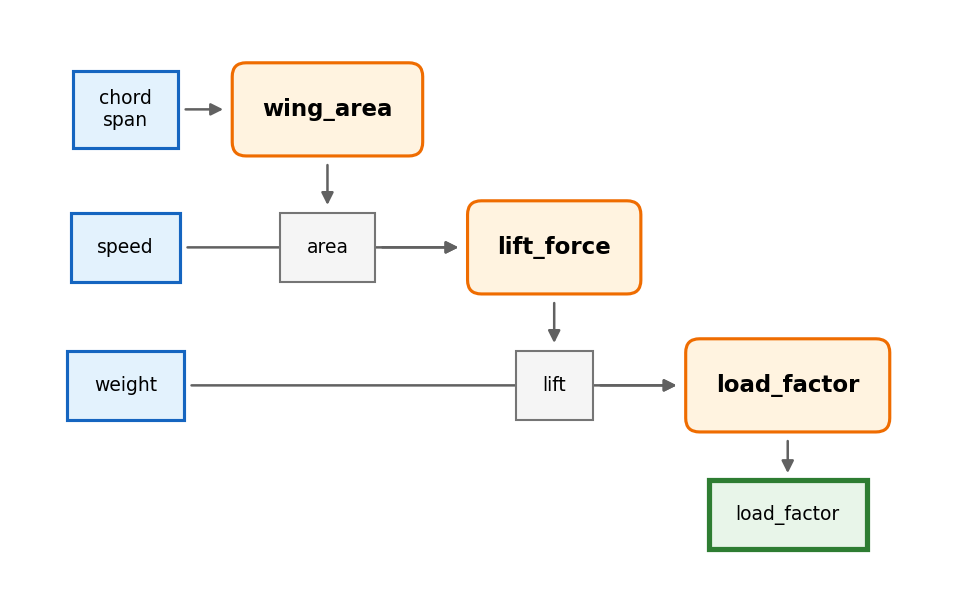

In [2]:
linear = Pipeline()

@linear.step(outputs=["area"])
def wing_area(span: float, chord: float) -> float:
    return span * chord

@linear.step(outputs=["lift"])
def lift_force(area: float, speed: float) -> float:
    return 0.5 * 1.225 * speed**2 * area * 1.2

@linear.step(outputs=["load_factor"])
def load_factor(lift: float, weight: float) -> float:
    return lift / weight

show(linear, ["span", "chord", "speed", "weight"], "linear")

**How to read an XDSM.** Disciplines sit on the **diagonal**, in the order they will actually
run. Off-diagonal boxes are the variables passed between them. The left column holds external
inputs, the bottom row the final outputs.

Follow the arrows: everything moves down and to the right. That is what *linear* looks like — no
arrow ever goes back up.

## A cyclic pipeline

Now one discipline consumes something a later one produces. There is no order that satisfies both,
so the loop has to be **iterated**.

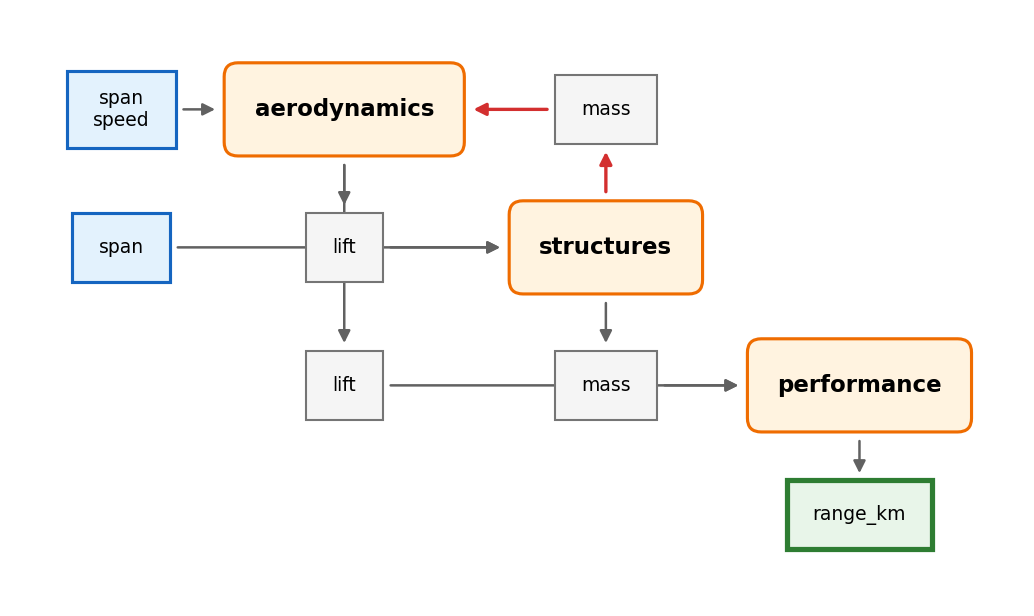

In [3]:
cyclic = Pipeline(solver=HybridSolver())

@cyclic.step(outputs=["lift"])
def aerodynamics(span: float, speed: float, mass: float) -> float:
    return 0.5 * 1.225 * speed**2 * span * 1.2

@cyclic.step(outputs=["mass"])
def structures(span: float, lift: float) -> float:
    return 200.0 + 0.5 * span + 0.001 * lift

@cyclic.step(outputs=["range_km"])
def performance(lift: float, mass: float) -> float:
    return 100.0 * lift / mass

show(cyclic, ["span", "speed"], "cyclic")

`aerodynamics` needs `mass`, and `structures` produces it from `lift`, which `aerodynamics`
produces. **That is the feedback edge** — the arrow running back up the diagonal, drawn in red.

You do not have to take the picture's word for it. The analysis agrees, and it is the same graph
decomposition the solver uses.

In [4]:
for label, pipeline, inputs in (("linear", linear, ["span", "chord", "speed", "weight"]),
                                ("cyclic", cyclic, ["span", "speed"])):
    report = analyze(pipeline, inputs=inputs)
    print(f"{label:7} has_cycles={report.has_cycles}  "
          f"recommended={report.recommended_solver}")
    for cycle in report.cycles:
        print(f"          loop: {' -> '.join(cycle.steps)} on {cycle.feedback_variables}")

linear  has_cycles=False  recommended=DAGSolver
cyclic  has_cycles=True  recommended=HybridSolver
          loop: aerodynamics -> structures on ('lift', 'mass')


That single visual difference — **is there a red arrow going back up?** — is what decides
everything in the next few notebooks: which solver to use, which variable needs a starting value,
and whether convergence is even a question.

## Missing inputs are drawn too

A variable nothing produces and nobody passed in is shown in its own column, in red. This is often
faster than reading a `KeyError`.

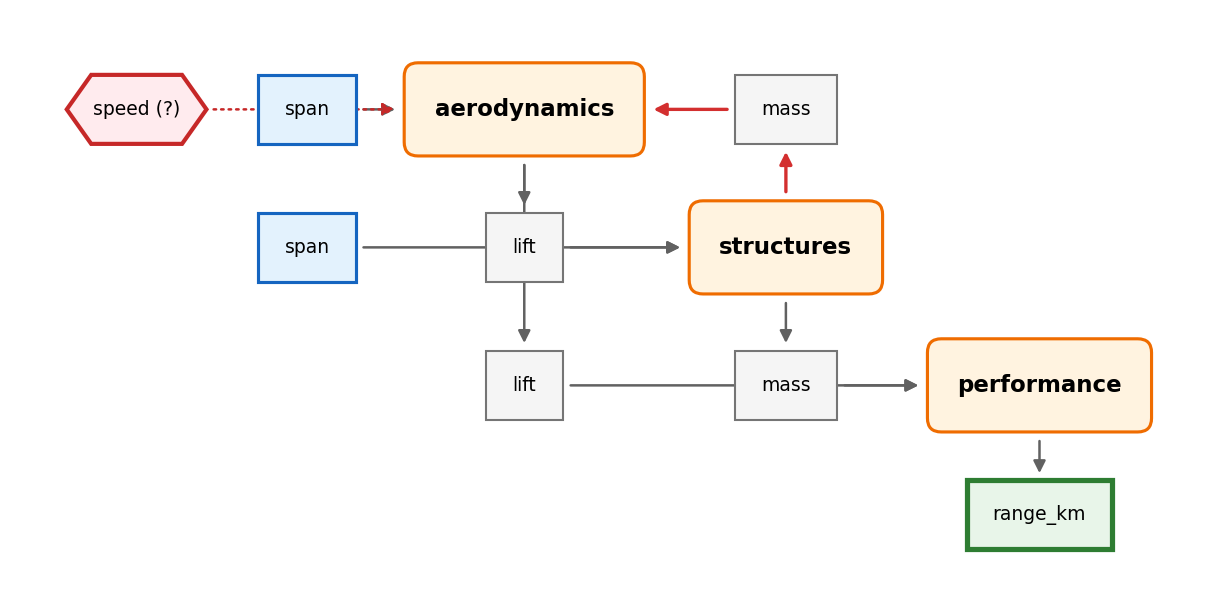

In [5]:
show(cyclic, ["span"], "missing")     # `speed` deliberately not supplied

## Keeping related steps together: groups

The diagonal follows execution order, and when a pipeline has **independent parts**, execution
order is free to alternate between them. Here, two data sources are loaded and cleaned separately,
then merged. Nothing about it is numerical: a pipeline is a pipeline.

ungrouped: ('load_sales', 'load_weather', 'clean_sales', 'clean_weather', 'merge')


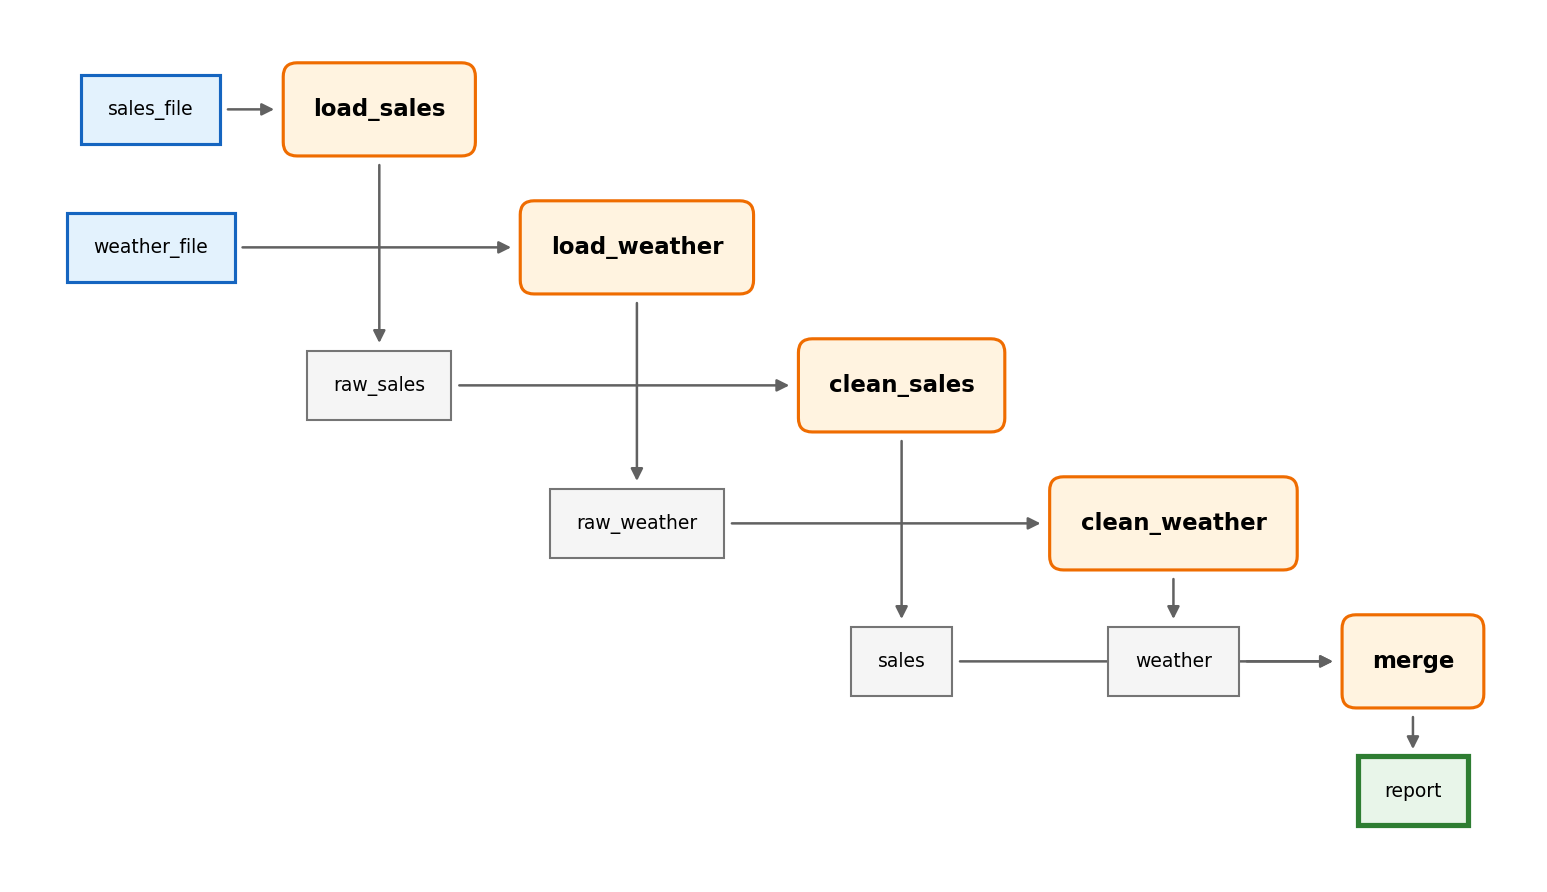

In [6]:
def workflow(grouped):
    g = (lambda name: name) if grouped else (lambda name: None)
    flow = Pipeline(inputs=["sales_file", "weather_file"])

    @flow.step(outputs=["raw_sales"], group=g("sales"))
    def load_sales(sales_file: str) -> list:
        return [3, 5, 8]

    @flow.step(outputs=["raw_weather"], group=g("weather"))
    def load_weather(weather_file: str) -> list:
        return [21, 19, 24]

    @flow.step(outputs=["sales"], group=g("sales"))
    def clean_sales(raw_sales: list) -> list:
        return [x for x in raw_sales if x > 0]

    @flow.step(outputs=["weather"], group=g("weather"))
    def clean_weather(raw_weather: list) -> list:
        return sorted(raw_weather)

    @flow.step(outputs=["report"])
    def merge(sales: list, weather: list) -> dict:
        return {"days": len(sales), "hottest": weather[-1]}

    return flow

print("ungrouped:", analyze(workflow(False)).execution_order)
show(workflow(False), ["sales_file", "weather_file"], "workflow_plain")

The two sources alternate down the diagonal. Declare a `group=` on each step and they stay
together — in the run *and* on the diagram, because both come from the same planner:

grouped:   ('load_sales', 'clean_sales', 'load_weather', 'clean_weather', 'merge')


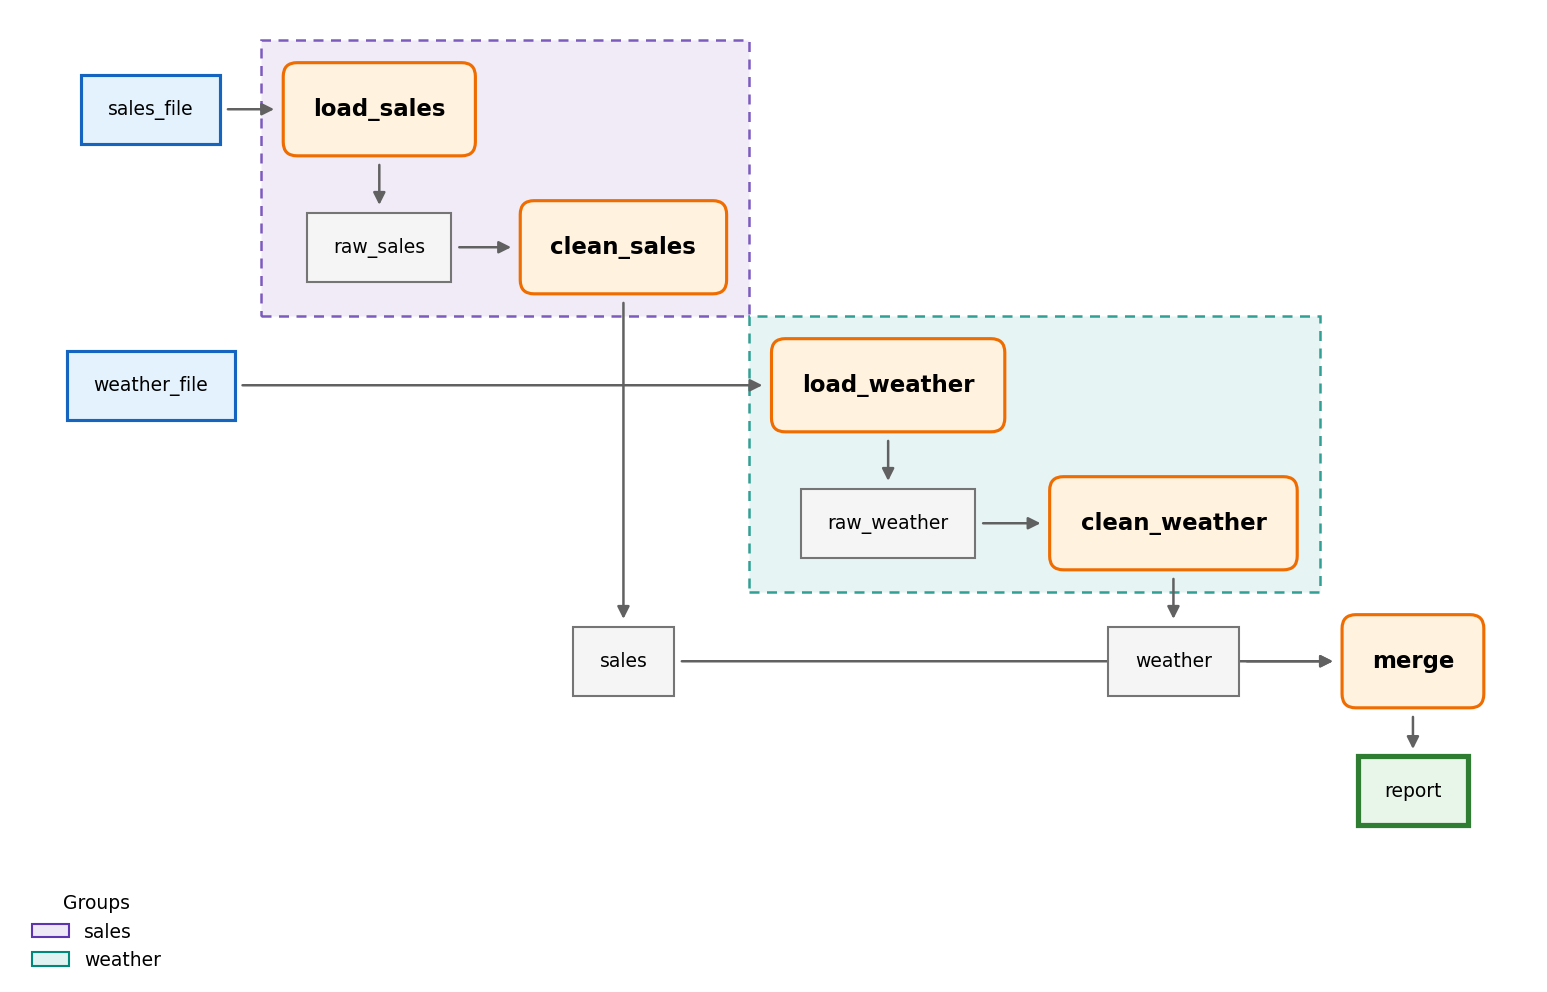

In [7]:
print("grouped:  ", analyze(workflow(True)).execution_order)
show(workflow(True), ["sales_file", "weather_file"], "workflow_grouped")

A group changes **nothing about what is computed** — only blocks that are independent anyway
change places. Both versions give the same report:

In [8]:
print(workflow(False).run(sales_file="s.csv", weather_file="w.csv")["report"])
print(workflow(True).run(sales_file="s.csv", weather_file="w.csv")["report"])

{'days': 3, 'hottest': 24}
{'days': 3, 'hottest': 24}


### When a group cannot stay together

If a dependency leaves a group and comes back into it, the step in between *must* sit between
the group's parts. The diagram draws the group as two bands, the legend marks it *split*, and
`validate()` names the dependencies that force it — so the split is explained, not just shown.

INFO: Groups 'review' and 'writing' cannot all be kept together: dependencies leave and re-enter them (write_draft -> review_draft, review_draft -> finalise). Those steps are placed in plain execution order.


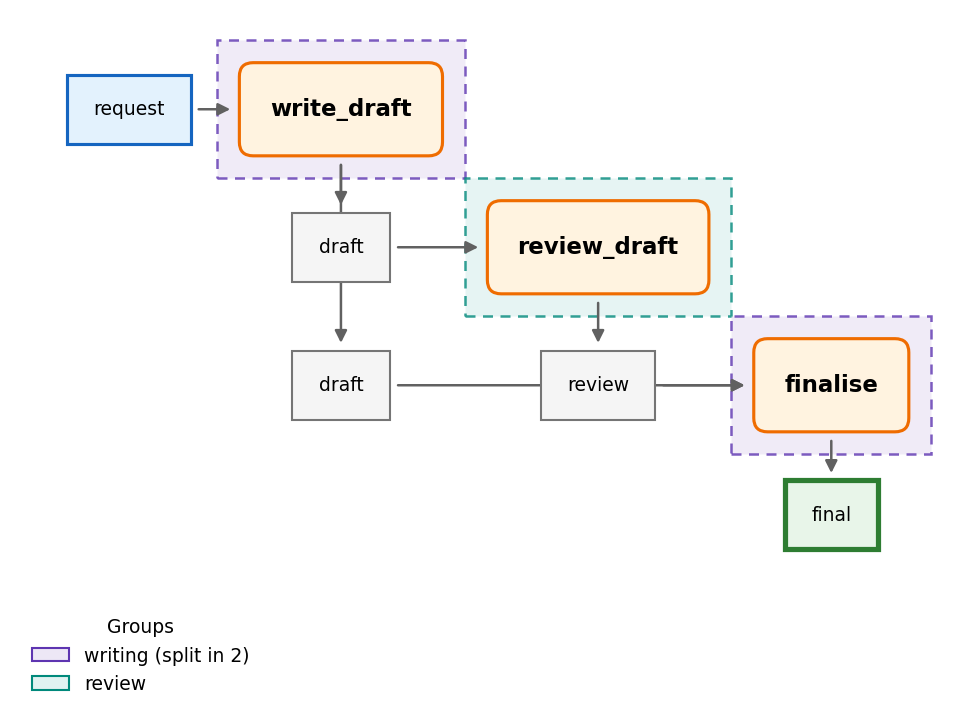

In [9]:
from smartmdao import validate

crossing = Pipeline(inputs=["request"])

@crossing.step(outputs=["draft"], group="writing")
def write_draft(request: str) -> str:
    return f"draft for {request}"

@crossing.step(outputs=["review"], group="review")
def review_draft(draft: str) -> str:
    return "looks good"

@crossing.step(outputs=["final"], group="writing")
def finalise(draft: str, review: str) -> str:
    return draft + " (reviewed)"

for finding in validate(crossing):
    print(finding)
show(crossing, ["request"], "crossing")

## Output format follows the extension

`.png` gives a raster; `.svg` and `.pdf` give vectors, which are what you want in a document.
Without an extension it defaults to PDF.

In [10]:
for suffix in (".png", ".svg", ".pdf"):
    path = gallery / f"aircraft{suffix}"
    cyclic.visualize(inputs=["span", "speed"], output_path=str(path), view=False)
    print(f"{suffix:5} -> {path.stat().st_size:8,} bytes")

.png  ->   31,268 bytes


.svg  ->   28,101 bytes


.pdf  ->   15,424 bytes


## The headless trap

**Always pass `view=False` outside a notebook with a display.** The default is `view=True`, which
calls `plt.show()` and blocks forever with no display attached.

The library deliberately does not force a backend on you, because that would change behaviour for
interactive users. So in a script, a CI job or a server, two things every time:

```python
matplotlib.use("Agg", force=True)
pipeline.visualize(..., view=False)
```

The MCP rendering path already does both, so diagrams requested through the connector are safe. A
direct call is not.

In [11]:
import shutil
shutil.rmtree(gallery)
print("cleaned up")

cleaned up


---

**Next:** [3 — Solvers](03-solvers.ipynb) — now that you can see whether a pipeline is cyclic, the
question is what to run it with.